# V21: Portfolio Strategy Comparison - AI & Graph Focus

This notebook evaluates the impact of adding a **Graph Filter (MIS)** to the AI-Gated portfolio. 
It compares the baseline Markowitz with AI-only gating, Graph-only selection, and the combined AI+Graph approach.

### Models in this Comparison:
1. **Markowitz Only**: Standard Mean-Variance Optimization.
2. **AI-Gated Markowitz**: Risk-On/Off based on AI (Random Forest) regime classification.
3. **AI + Graph**: AI-Gating combined with Graph-based (MIS) asset selection.
4. **AI + HMM + Graph**: Triple layer (Global HMM + AI Gate + Graph Filter) - The most conservative.
5. **BTC Benchmark**: Buy and Hold Bitcoin.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = '../dataset_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 990 rows


In [2]:
# --- 2. Model Training ---
print("Training AI and HMM Gatekeepers...")

# AI Layer (Regime Prediction)
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
ai_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

# Global HMM Layer
market_log_ret = np.log1p(market_return).replace([np.inf, -np.inf], np.nan).dropna()
global_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
global_hmm.fit(market_log_ret.values.reshape(-1, 1))
bull_state = np.argmax([global_hmm.means_[i][0] for i in range(2)])
hmm_regimes = pd.Series(global_hmm.predict(market_log_ret.values.reshape(-1, 1)) == bull_state, index=market_log_ret.index).astype(int)

print("✓ Training Complete.")

Training AI and HMM Gatekeepers...
✓ Training Complete.


In [3]:
# --- 3. Core Strategy Logic ---

def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    
    def neg_sharpe(weights):
        port_ret = np.sum(weights * mu)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_ret / port_vol if port_vol > 0.0001 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    guess = [1. / len(mu)] * len(mu)
    
    try:
        res = minimize(neg_sharpe, guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_returns.columns, res.x)) if res.success else dict(zip(selected_returns.columns, guess))
    except:
        return dict(zip(selected_returns.columns, guess))

def run_simulation(strategy_type, test_dates, returns, ai_probs, hmm_regimes, lookback=30, cor_t=0.5):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    weights_log = []
    
    for i, date in enumerate(test_dates[:-1]):
        # 1. Gate Logic
        ai_off = ai_probs.loc[date] < 0.5
        hmm_off = hmm_regimes.reindex(test_dates, method='ffill').loc[date] == 0
        
        is_risk_off = False
        if strategy_type == 'AI-Gated': is_risk_off = ai_off
        elif strategy_type == 'AI+Graph': is_risk_off = ai_off
        elif strategy_type == 'Full (AI+HMM+Graph)': is_risk_off = ai_off or hmm_off
        
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if is_risk_off:
            weights = {'CASH': 1.0}
        else:
            use_graph = 'Graph' in strategy_type
            if use_graph:
                selected = get_mis_assets(window_rets, correlation_threshold=cor_t)
                weights = optimize_markowitz(window_rets[selected])
            else:
                weights = optimize_markowitz(window_rets)
        
        weights_log.append(weights)
        
        # 2. PnL Calculation
        next_date = test_dates[i+1]
        next_rets = returns.loc[next_date]
        day_ret = 0 if 'CASH' in weights else sum(w * next_rets[a] for a, w in weights.items())
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), weights_log

In [4]:
# --- 4. Backtest Execution ---
test_dates = ai_probs.index
results = {}
all_weights = {}

sim_configs = [
    ('Markowitz Only', 'Markowitz Only'),
    ('AI-Gated', 'AI-Gated Markowitz'),
    ('AI+Graph', 'AI + Graph Enhanced'),
    ('Full (AI+HMM+Graph)', 'Full (AI+HMM+Graph)')
]

for s_type, label in sim_configs:
    print(f"Running sim: {label}...")
    df, w = run_simulation(s_type, test_dates, returns, ai_probs, hmm_regimes)
    results[label] = df
    all_weights[label] = w

# BTC Benchmark
btc = data.loc[test_dates, 'BTC-USD']
results['Buy and Hold (BTC)'] = pd.DataFrame({'Portfolio_Value': (btc / btc.iloc[0] * 100)}, index=test_dates)

print("✓ Backtests Finished.")

Running sim: Markowitz Only...
Running sim: AI-Gated Markowitz...
Running sim: AI + Graph Enhanced...
Running sim: Full (AI+HMM+Graph)...
✓ Backtests Finished.


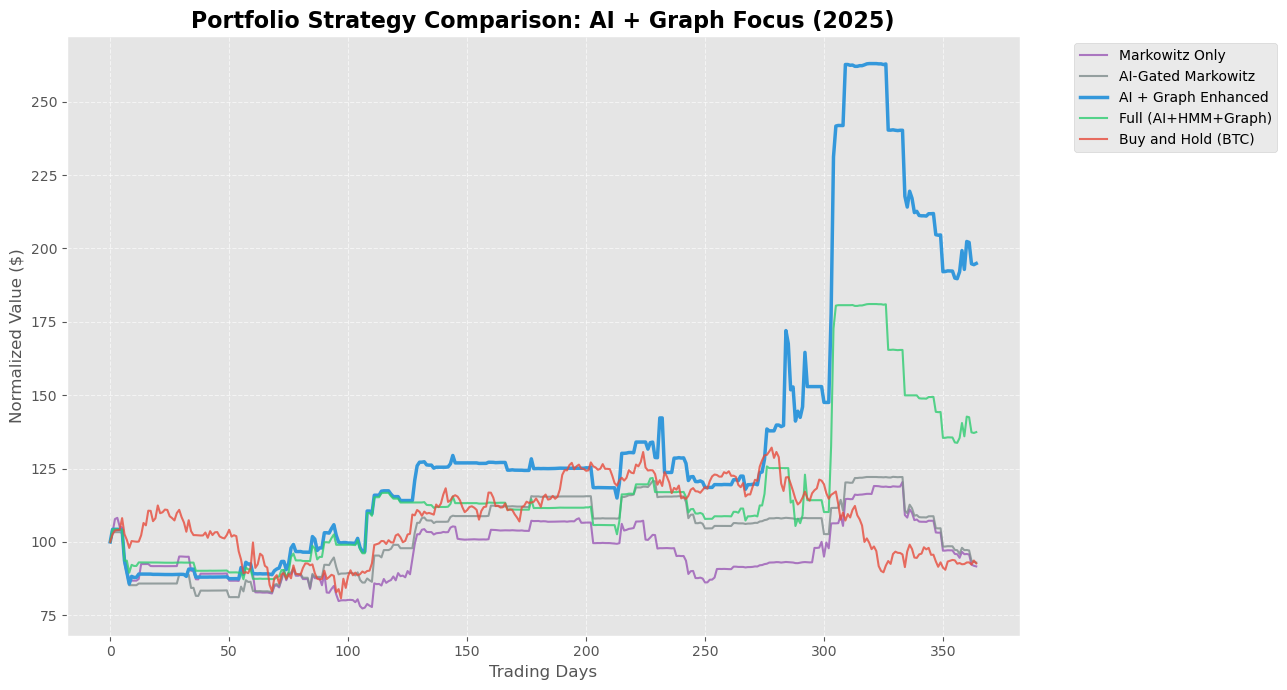

In [5]:
# --- 5. Visualization (AI + Graph Highlight) ---
plt.figure(figsize=(13, 7))

# Color palette inspired by the target image
colors = {'Markowitz Only': '#9b59b6', 
          'AI-Gated Markowitz': '#7f8c8d', 
          'AI + Graph Enhanced': '#3498db',
          'Full (AI+HMM+Graph)': '#2ecc71', 
          'Buy and Hold (BTC)': '#e74c3c'}

trading_days = np.arange(len(test_dates))

for label, df in results.items():
    lw = 2.5 if 'AI + Graph' in label else 1.5
    alpha = 1.0 if 'AI + Graph' in label else 0.8
    plt.plot(trading_days, df['Portfolio_Value'], label=label, linewidth=lw, alpha=alpha, color=colors.get(label))

plt.title('Portfolio Strategy Comparison: AI + Graph Focus (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Normalized Value ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('v21_ai_graph_comparison.png', dpi=300)
plt.show()

In [6]:
# --- 6. Final Export ---
output_excel = "v21_ai_graph_enhanced_results.xlsx"
with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    for label, df in results.items():
        # Clean sheet name for Excel
        sheet_name = label.replace("(", "").replace(")", "")[:31]
        df.to_excel(writer, sheet_name=sheet_name)
        
print(f"✅ Done! Results saved to {output_excel}")

✅ Done! Results saved to v21_ai_graph_enhanced_results.xlsx
